In [2]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel(r'E:\Learnings\WFM\wfm-forecasting-dashboard\data\Call-Center-Dataset.xlsx')

In [7]:
df['date_only'] = df['Date'].dt.date
daily_volume=df.groupby('date_only').size().reset_index()
daily_volume.columns=['ds','y']
daily_volume['ds']=pd.to_datetime(daily_volume['ds'])

In [8]:
print(daily_volume.head(10))
print(f"\nShape: {daily_volume.shape}")
print(f"Date range: {daily_volume['ds'].min()} to {daily_volume['ds'].max()}")

          ds   y
0 2015-01-01  58
1 2015-01-02  60
2 2015-01-03  58
3 2015-01-04  54
4 2015-01-05  56
5 2015-01-06  58
6 2015-01-07  54
7 2015-01-08  48
8 2015-01-09  68
9 2015-01-10  64

Shape: (90, 2)
Date range: 2015-01-01 00:00:00 to 2015-03-31 00:00:00


11:05:11 - cmdstanpy - INFO - Chain [1] start processing
11:05:11 - cmdstanpy - INFO - Chain [1] done processing


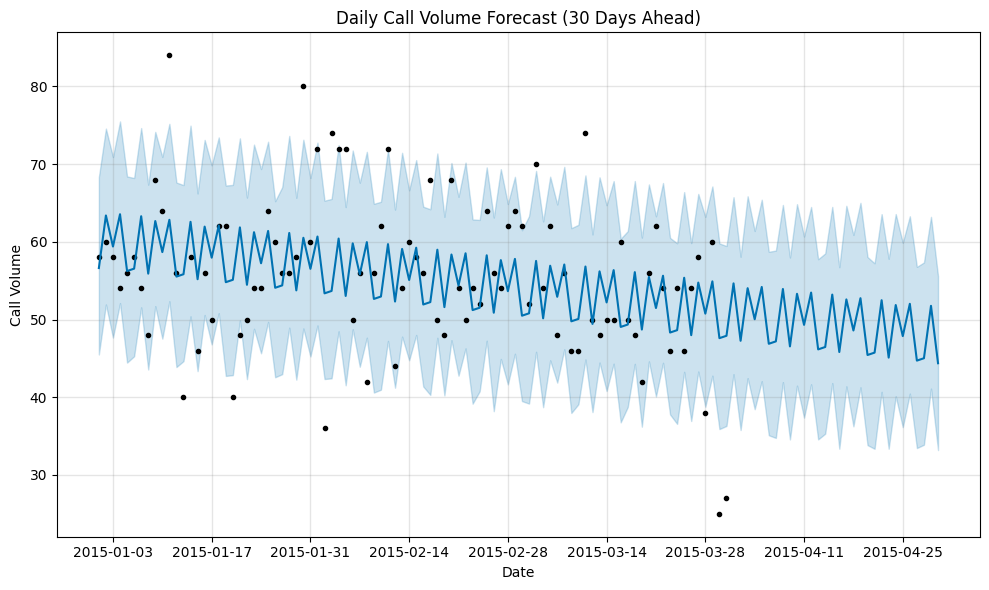

In [12]:
model= Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False
)
model.fit(daily_volume)

future=model.make_future_dataframe(periods=30)

forecast=model.predict(future)

fig = model.plot(forecast)
plt.title('Daily Call Volume Forecast (30 Days Ahead)')
plt.xlabel('Date')
plt.ylabel('Call Volume')
plt.tight_layout()
plt.show()

In [13]:
# Show forecast for the 30 future days
future_only = forecast[forecast['ds'] > '2015-03-31'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
future_only['yhat'] = future_only['yhat'].round(0)
future_only['yhat_lower'] = future_only['yhat_lower'].round(0)
future_only['yhat_upper'] = future_only['yhat_upper'].round(0)

print(future_only.to_string(index=False))
print(f"\nAverage forecasted daily volume: {future_only['yhat'].mean():.0f}")

        ds  yhat  yhat_lower  yhat_upper
2015-04-01  55.0        43.0        66.0
2015-04-02  47.0        36.0        58.0
2015-04-03  54.0        42.0        66.0
2015-04-04  50.0        38.0        61.0
2015-04-05  54.0        42.0        65.0
2015-04-06  47.0        35.0        59.0
2015-04-07  47.0        35.0        59.0
2015-04-08  54.0        42.0        65.0
2015-04-09  47.0        35.0        58.0
2015-04-10  53.0        41.0        65.0
2015-04-11  49.0        37.0        61.0
2015-04-12  53.0        42.0        64.0
2015-04-13  46.0        35.0        58.0
2015-04-14  46.0        35.0        59.0
2015-04-15  53.0        42.0        64.0
2015-04-16  46.0        33.0        57.0
2015-04-17  53.0        41.0        65.0
2015-04-18  49.0        36.0        61.0
2015-04-19  53.0        41.0        65.0
2015-04-20  45.0        34.0        58.0
2015-04-21  46.0        33.0        57.0
2015-04-22  52.0        41.0        64.0
2015-04-23  45.0        33.0        58.0
2015-04-24  52.0

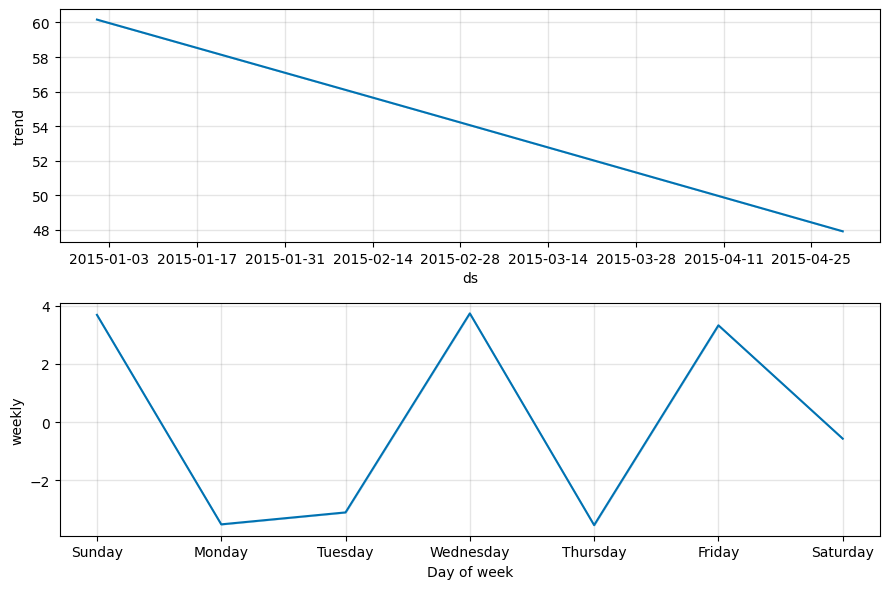

In [14]:
# Show weekly seasonality pattern
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

### Forecasting Model Summary
- Model: Facebook Prophet (daily granularity)
- Training data: 90 days (Jan 1 - Mar 31, 2015)
- Forecast horizon: 30 days (April 2015)
- Settings: weekly seasonality ON, daily and yearly OFF
- Average forecasted daily volume: 49 calls/day (vs ~55 historical)
- Slight downward trend detected — may be noise given limited data
- Weekly seasonality captured: subtle day-of-week variation
- Uncertainty range: ±12 calls/day — wide due to short training period
- Key limitation: 90 days is below Prophet's recommended minimum (1-2 years) for reliable forecasting

In [15]:
# Export forecast to CSV for Erlang C model
future_only.to_csv(r'E:\Learnings\WFM\wfm-forecasting-dashboard\data\forecast_april.csv', index=False)
print("Forecast saved to data/forecast_april.csv")

Forecast saved to data/forecast_april.csv


In [16]:
import pandas as pd

In [18]:
forecast_df=pd.read_csv(r'E:\Learnings\WFM\wfm-forecasting-dashboard\data\forecast_april.csv')

In [19]:
hourly_dist = {
    9: 0.110, 10: 0.106, 11: 0.118, 12: 0.110,
    13: 0.119, 14: 0.100, 15: 0.107, 16: 0.114, 17: 0.117
}

In [20]:
rows = []
for _, day in forecast_df.iterrows():
    for hour, pct in hourly_dist.items():
        rows.append({
            'date': day['ds'],
            'hour': hour,
            'forecasted_calls': round(day['yhat'] * pct, 1),
            'forecast_low': round(day['yhat_lower'] * pct, 1),
            'forecast_high': round(day['yhat_upper'] * pct, 1)
        })

In [21]:
hourly_forecast = pd.DataFrame(rows)

In [22]:
hourly_forecast.to_csv(r'E:\Learnings\WFM\wfm-forecasting-dashboard\data\hourly_forecast.csv', index=False)


In [23]:
print(hourly_forecast.head(18))
print(f"\nTotal rows: {len(hourly_forecast)}")
print("Saved to data/hourly_forecast.csv")

          date  hour  forecasted_calls  forecast_low  forecast_high
0   2015-04-01     9               6.0           4.7            7.3
1   2015-04-01    10               5.8           4.6            7.0
2   2015-04-01    11               6.5           5.1            7.8
3   2015-04-01    12               6.0           4.7            7.3
4   2015-04-01    13               6.5           5.1            7.9
5   2015-04-01    14               5.5           4.3            6.6
6   2015-04-01    15               5.9           4.6            7.1
7   2015-04-01    16               6.3           4.9            7.5
8   2015-04-01    17               6.4           5.0            7.7
9   2015-04-02     9               5.2           4.0            6.4
10  2015-04-02    10               5.0           3.8            6.1
11  2015-04-02    11               5.5           4.2            6.8
12  2015-04-02    12               5.2           4.0            6.4
13  2015-04-02    13               5.6          